In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report,
    roc_auc_score, roc_curve
)

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
df = pd.read_csv("Risk_Alert_Classifier_Dataset.csv")
df.columns = df.columns.str.strip()
print("Shape:", df.shape)
print(df.head())

Shape: (4600, 19)
   customer_id   age  gender   region employment_type  annual_income_inr  \
0       500001  43.0  Female      NaN        Salaried            82242.0   
1       500002  29.0  Female  Central        Salaried            32769.0   
2       500003  36.0    Male     East        Salaried            39731.0   
3       500004  28.0    Male    North      Unemployed            38990.0   
4       500005  36.0  Female     East   Self-Employed            41043.0   

   credit_score  credit_utilization_ratio  missed_payments_12m  \
0           NaN                     0.120                    1   
1         647.0                     0.337                    1   
2         727.0                     0.175                    0   
3         553.0                     0.472                    7   
4         732.0                     0.418                    1   

   avg_late_payment_days  monthly_transaction_count  monthly_spend_inr  \
0                    2.2                         39   

In [ ]:
print("Missing values:\n", df.isnull().sum())

print("\nClass Distribution:")
print(df['risk_status'].value_counts())
print(df['risk_status'].value_counts(normalize=True).mul(100).round(2))

Missing values:
 customer_id                    0
age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64

Class Distribution:
risk_status
0    4043
1     557
Name: count, dtype: int64
risk_status
0    87.89
1    12.11
Name: proportion, dtype: float64


In [ ]:
def preprocess(df):
    data = df.copy()

    data.drop(columns=['customer_id', 'last_transaction_date'], inplace=True, errors='ignore')

    for col in ['region', 'employment_type', 'gender']:
        if col in data.columns:
            data[col].fillna(data[col].mode()[0], inplace=True)

    numeric_cols = ['age', 'annual_income_inr', 'credit_score',
                    'credit_utilization_ratio', 'monthly_spend_inr']
    imputer = KNNImputer(n_neighbors=5)
    data[numeric_cols] = imputer.fit_transform(data[numeric_cols])

    le = LabelEncoder()
    for col in ['gender', 'region', 'employment_type']:
        if col in data.columns:
            data[col] = le.fit_transform(data[col].astype(str))

    return data

df_clean = preprocess(df)

X = df_clean.drop('risk_status', axis=1)
y = df_clean['risk_status']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)
print("Train class distribution:\n", y_train.value_counts())

Training Set: (3680, 16)
Testing Set : (920, 16)
Train class distribution:
 risk_status
0    3234
1     446
Name: count, dtype: int64



  Model: Logistic Regression (Baseline)
Confusion Matrix:
[[809   0]
 [  0 111]]

Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
AUC-ROC   : 1.0000

Type-I  Error (False Positives) : 0
Type-II Error (False Negatives) : 0

Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       809
   High Risk       1.00      1.00      1.00       111

    accuracy                           1.00       920
   macro avg       1.00      1.00      1.00       920
weighted avg       1.00      1.00      1.00       920



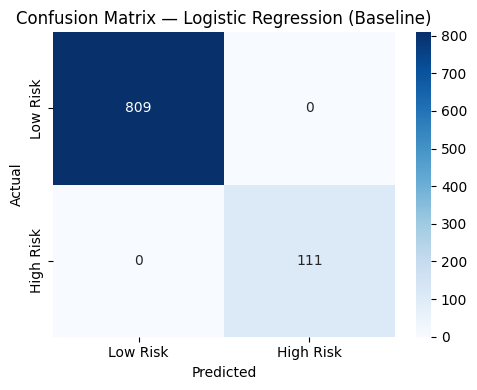

In [ ]:
def evaluate_model(name, y_test, y_pred, y_prob=None):
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()

   
    print(cm)
    print(f"\nAccuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
    if y_prob is not None:
        print(f"AUC-ROC   : {roc_auc_score(y_test, y_prob):.4f}")
    
    print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk']))

    # Confusion matrix heatmap
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low Risk', 'High Risk'],
                yticklabels=['Low Risk', 'High Risk'])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

evaluate_model("Logistic Regression (Baseline)", y_test, y_pred_lr, y_prob_lr)


Under-Sampling — class counts: {0: 446, 1: 446}

  Model: LR + Under-Sampling
Confusion Matrix:
[[805   4]
 [  0 111]]

Accuracy  : 0.9957
Precision : 0.9652
Recall    : 1.0000
F1 Score  : 0.9823
AUC-ROC   : 1.0000

Type-I  Error (False Positives) : 4
Type-II Error (False Negatives) : 0

Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       809
   High Risk       0.97      1.00      0.98       111

    accuracy                           1.00       920
   macro avg       0.98      1.00      0.99       920
weighted avg       1.00      1.00      1.00       920



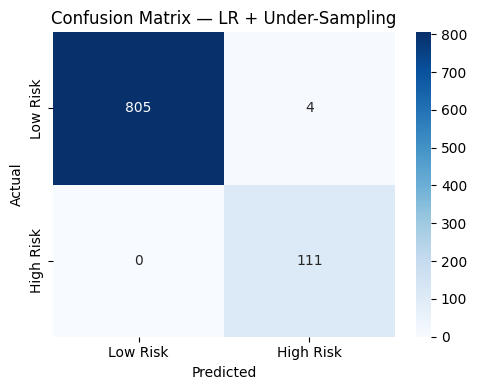


Over-Sampling — class counts: {0: 3234, 1: 3234}

  Model: LR + Over-Sampling
Confusion Matrix:
[[806   3]
 [  0 111]]

Accuracy  : 0.9967
Precision : 0.9737
Recall    : 1.0000
F1 Score  : 0.9867
AUC-ROC   : 1.0000

Type-I  Error (False Positives) : 3
Type-II Error (False Negatives) : 0

Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       809
   High Risk       0.97      1.00      0.99       111

    accuracy                           1.00       920
   macro avg       0.99      1.00      0.99       920
weighted avg       1.00      1.00      1.00       920



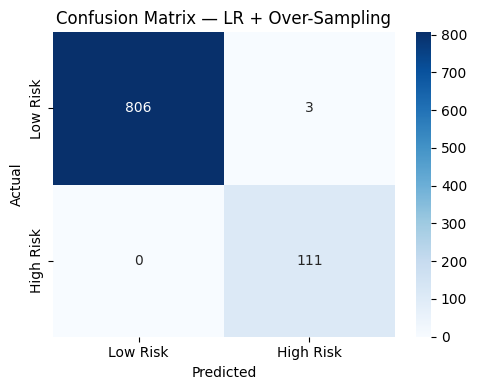


SMOTE — class counts: {0: 3234, 1: 3234}

  Model: LR + SMOTE
Confusion Matrix:
[[806   3]
 [  0 111]]

Accuracy  : 0.9967
Precision : 0.9737
Recall    : 1.0000
F1 Score  : 0.9867
AUC-ROC   : 1.0000

Type-I  Error (False Positives) : 3
Type-II Error (False Negatives) : 0

Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       809
   High Risk       0.97      1.00      0.99       111

    accuracy                           1.00       920
   macro avg       0.99      1.00      0.99       920
weighted avg       1.00      1.00      1.00       920



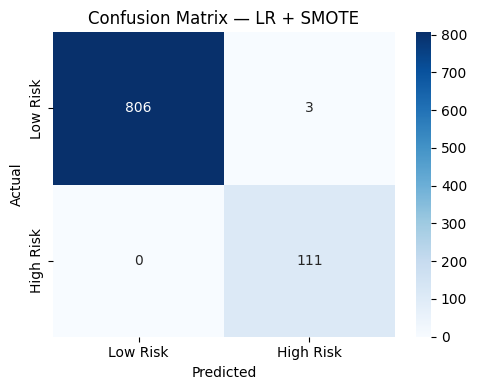


ADASYN — class counts: {1: 3246, 0: 3234}

  Model: LR + ADASYN
Confusion Matrix:
[[801   8]
 [  0 111]]

Accuracy  : 0.9913
Precision : 0.9328
Recall    : 1.0000
F1 Score  : 0.9652
AUC-ROC   : 1.0000

Type-I  Error (False Positives) : 8
Type-II Error (False Negatives) : 0

Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      0.99      1.00       809
   High Risk       0.93      1.00      0.97       111

    accuracy                           0.99       920
   macro avg       0.97      1.00      0.98       920
weighted avg       0.99      0.99      0.99       920



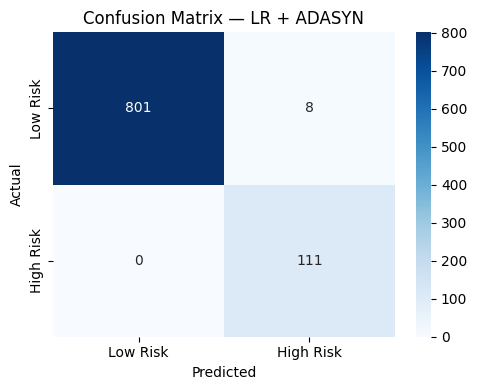


── Sampling Technique Comparison ──
                        Recall      F1  AUC-ROC
Baseline (No Sampling)     1.0  1.0000      1.0
Under-Sampling             1.0  0.9823      1.0
Over-Sampling              1.0  0.9867      1.0
SMOTE                      1.0  0.9867      1.0
ADASYN                     1.0  0.9652      1.0


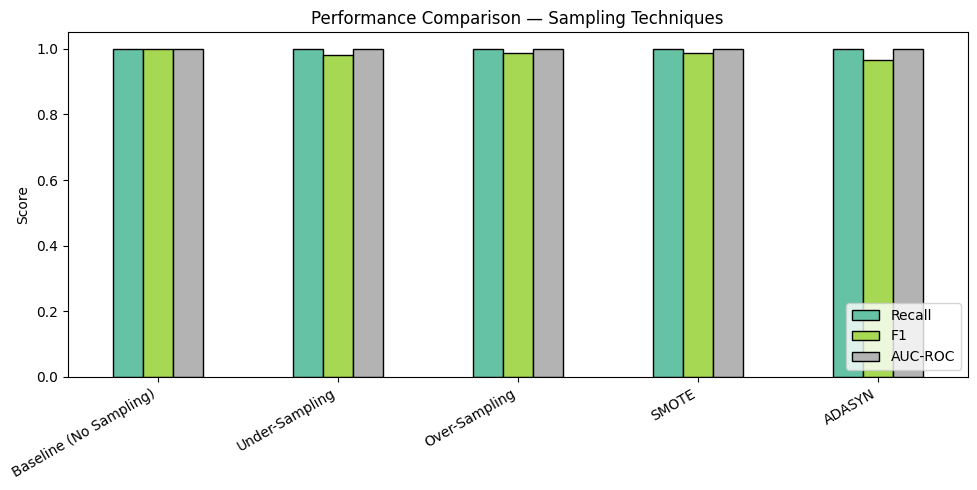

In [ ]:
samplers = {
    'Under-Sampling' : RandomUnderSampler(random_state=42),
    'Over-Sampling'  : RandomOverSampler(random_state=42),
    'SMOTE'          : SMOTE(random_state=42),
    'ADASYN'         : ADASYN(random_state=42)
}

results = {}

results['Baseline (No Sampling)'] = {
    'Recall'  : recall_score(y_test, y_pred_lr),
    'F1'      : f1_score(y_test, y_pred_lr),
    'AUC-ROC' : roc_auc_score(y_test, y_prob_lr)
}

roc_data = {'Baseline': (y_test, y_prob_lr)}

for name, sampler in samplers.items():
    X_res, y_res = sampler.fit_resample(X_train, y_train)
    print(f"\n{name} — class counts: {pd.Series(y_res).value_counts().to_dict()}")

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_res, y_res)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    evaluate_model(f"LR + {name}", y_test, y_pred, y_prob)

    results[name] = {
        'Recall'  : recall_score(y_test, y_pred),
        'F1'      : f1_score(y_test, y_pred),
        'AUC-ROC' : roc_auc_score(y_test, y_prob)
    }
    roc_data[name] = (y_test, y_prob)

results_df = pd.DataFrame(results).T.round(4)
print("\n── Sampling Technique Comparison ──")
print(results_df)

results_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Performance Comparison — Sampling Techniques')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

=== Decision Tree ===
Train Accuracy : 1.0000
Test  Accuracy : 0.9783
>> Large gap between train/test = OVERFITTING

  Model: Decision Tree
Confusion Matrix:
[[798  11]
 [  9 102]]

Accuracy  : 0.9783
Precision : 0.9027
Recall    : 0.9189
F1 Score  : 0.9107
AUC-ROC   : 0.9527

Type-I  Error (False Positives) : 11
Type-II Error (False Negatives) : 9

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.99      0.99      0.99       809
   High Risk       0.90      0.92      0.91       111

    accuracy                           0.98       920
   macro avg       0.95      0.95      0.95       920
weighted avg       0.98      0.98      0.98       920



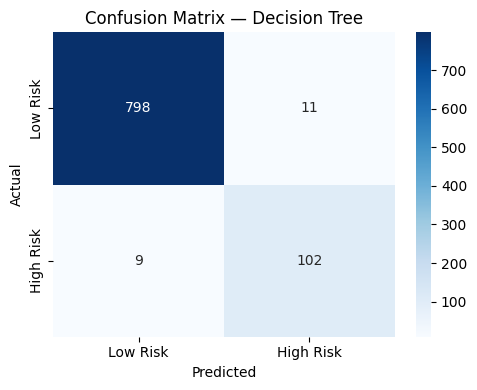

=== Random Forest ===
Train Accuracy : 1.0000
Test  Accuracy : 0.9957

  Model: Random Forest
Confusion Matrix:
[[807   2]
 [  2 109]]

Accuracy  : 0.9957
Precision : 0.9820
Recall    : 0.9820
F1 Score  : 0.9820
AUC-ROC   : 0.9998

Type-I  Error (False Positives) : 2
Type-II Error (False Negatives) : 2

Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       809
   High Risk       0.98      0.98      0.98       111

    accuracy                           1.00       920
   macro avg       0.99      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



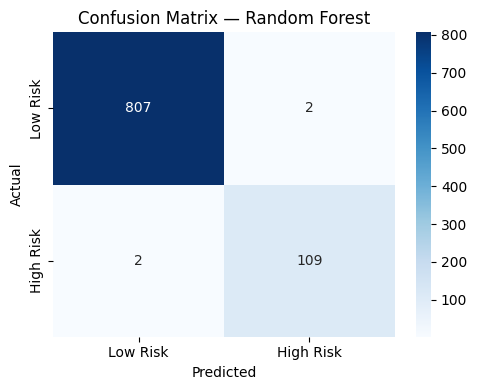


── Decision Tree vs Random Forest ──
          Decision Tree  Random Forest
Accuracy         0.9783         0.9957
Recall           0.9189         0.9820
F1               0.9107         0.9820
AUC-ROC          0.9527         0.9998


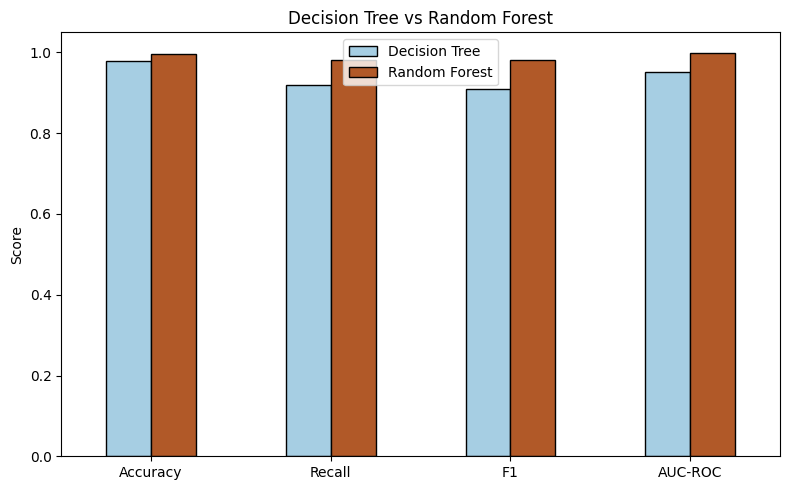

In [ ]:
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train, y_train)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_sm, y_sm)

y_pred_dt_train = dt.predict(X_sm)
y_pred_dt_test  = dt.predict(X_test)
y_prob_dt       = dt.predict_proba(X_test)[:, 1]

print("=== Decision Tree ===")
print(f"Train Accuracy : {accuracy_score(y_sm, y_pred_dt_train):.4f}")
print(f"Test  Accuracy : {accuracy_score(y_test, y_pred_dt_test):.4f}")
print(">> Large gap between train/test = OVERFITTING")
evaluate_model("Decision Tree", y_test, y_pred_dt_test, y_prob_dt)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_sm, y_sm)

y_pred_rf_train = rf.predict(X_sm)
y_pred_rf_test  = rf.predict(X_test)
y_prob_rf       = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(f"Train Accuracy : {accuracy_score(y_sm, y_pred_rf_train):.4f}")
print(f"Test  Accuracy : {accuracy_score(y_test, y_pred_rf_test):.4f}")
evaluate_model("Random Forest", y_test, y_pred_rf_test, y_prob_rf)

comparison = pd.DataFrame({
    'Decision Tree' : [
        accuracy_score(y_test, y_pred_dt_test),
        recall_score(y_test, y_pred_dt_test),
        f1_score(y_test, y_pred_dt_test),
        roc_auc_score(y_test, y_prob_dt)
    ],
    'Random Forest' : [
        accuracy_score(y_test, y_pred_rf_test),
        recall_score(y_test, y_pred_rf_test),
        f1_score(y_test, y_pred_rf_test),
        roc_auc_score(y_test, y_prob_rf)
    ]
}, index=['Accuracy', 'Recall', 'F1', 'AUC-ROC']).round(4)

print("\n── Decision Tree vs Random Forest ──")
print(comparison)

comparison.plot(kind='bar', figsize=(8, 5), colormap='Paired', edgecolor='black')
plt.title('Decision Tree vs Random Forest')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Best DT params (RandomizedSearchCV): {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15, 'criterion': 'entropy'}
Best RF params (RandomizedSearchCV): {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Best RF params (GridSearchCV): {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}

  Model: Decision Tree (Tuned)
Confusion Matrix:
[[802   7]
 [  8 103]]

Accuracy  : 0.9837
Precision : 0.9364
Recall    : 0.9279
F1 Score  : 0.9321
AUC-ROC   : 0.9596

Type-I  Error (False Positives) : 7
Type-II Error (False Negatives) : 8

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.99      0.99      0.99       809
   High Risk       0.94      0.93      0.93       111

    accuracy                           0.98       920
   macro avg       0.96      0.96      0.96       920
weighted avg       0.98      0.98      0.98  

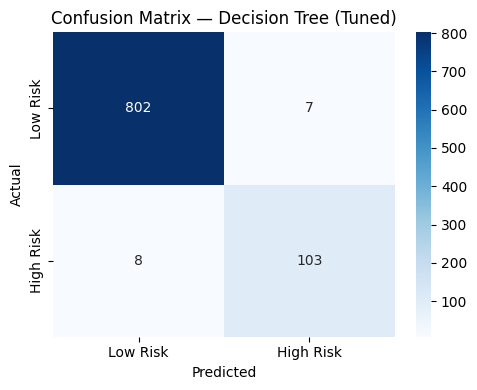


  Model: Random Forest (Tuned)
Confusion Matrix:
[[807   2]
 [  3 108]]

Accuracy  : 0.9946
Precision : 0.9818
Recall    : 0.9730
F1 Score  : 0.9774
AUC-ROC   : 0.9998

Type-I  Error (False Positives) : 2
Type-II Error (False Negatives) : 3

Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       809
   High Risk       0.98      0.97      0.98       111

    accuracy                           0.99       920
   macro avg       0.99      0.99      0.99       920
weighted avg       0.99      0.99      0.99       920



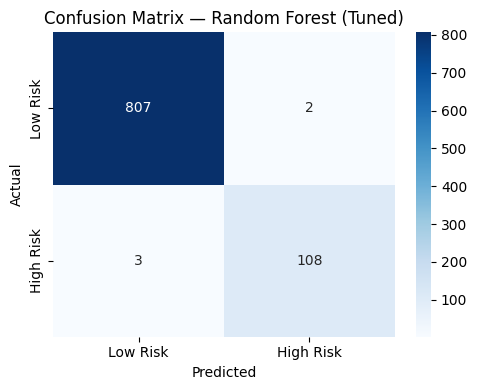


── Tuned vs Untuned ──
          RF Untuned  RF Tuned
Accuracy      0.9957    0.9946
Recall        0.9820    0.9730
F1            0.9820    0.9774
AUC-ROC       0.9998    0.9998


In [ ]:
dt_param_dist = {
    'max_depth'        : [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 4, 8],
    'criterion'        : ['gini', 'entropy']
}

dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_dist, n_iter=20, cv=5,
    scoring='recall', random_state=42, n_jobs=-1
)
dt_random.fit(X_sm, y_sm)
print("Best DT params (RandomizedSearchCV):", dt_random.best_params_)

rf_param_dist = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_dist, n_iter=20, cv=5,
    scoring='recall', random_state=42, n_jobs=-1
)
rf_random.fit(X_sm, y_sm)
print("Best RF params (RandomizedSearchCV):", rf_random.best_params_)

best_rf_params = rf_random.best_params_
rf_grid_params = {
    'n_estimators' : [best_rf_params['n_estimators'] - 50,
                      best_rf_params['n_estimators'],
                      best_rf_params['n_estimators'] + 50],
    'max_depth'    : [best_rf_params['max_depth']],
    'min_samples_split': [best_rf_params['min_samples_split']],
    'min_samples_leaf' : [best_rf_params['min_samples_leaf']],
    'max_features' : [best_rf_params['max_features']]
}
rf_grid_params['n_estimators'] = [max(10, n) for n in rf_grid_params['n_estimators']]

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_grid_params, cv=5, scoring='recall', n_jobs=-1
)
rf_grid.fit(X_sm, y_sm)
print("\nBest RF params (GridSearchCV):", rf_grid.best_params_)

best_dt_tuned = dt_random.best_estimator_
best_rf_tuned = rf_grid.best_estimator_

y_pred_dt_tuned = best_dt_tuned.predict(X_test)
y_prob_dt_tuned = best_dt_tuned.predict_proba(X_test)[:, 1]

y_pred_rf_tuned = best_rf_tuned.predict(X_test)
y_prob_rf_tuned = best_rf_tuned.predict_proba(X_test)[:, 1]

evaluate_model("Decision Tree (Tuned)", y_test, y_pred_dt_tuned, y_prob_dt_tuned)
evaluate_model("Random Forest (Tuned)", y_test, y_pred_rf_tuned, y_prob_rf_tuned)

tuning_comparison = pd.DataFrame({
    'RF Untuned': [
        accuracy_score(y_test, y_pred_rf_test),
        recall_score(y_test, y_pred_rf_test),
        f1_score(y_test, y_pred_rf_test),
        roc_auc_score(y_test, y_prob_rf)
    ],
    'RF Tuned': [
        accuracy_score(y_test, y_pred_rf_tuned),
        recall_score(y_test, y_pred_rf_tuned),
        f1_score(y_test, y_pred_rf_tuned),
        roc_auc_score(y_test, y_prob_rf_tuned)
    ]
}, index=['Accuracy', 'Recall', 'F1', 'AUC-ROC']).round(4)

print("\n── Tuned vs Untuned ──")
print(tuning_comparison)

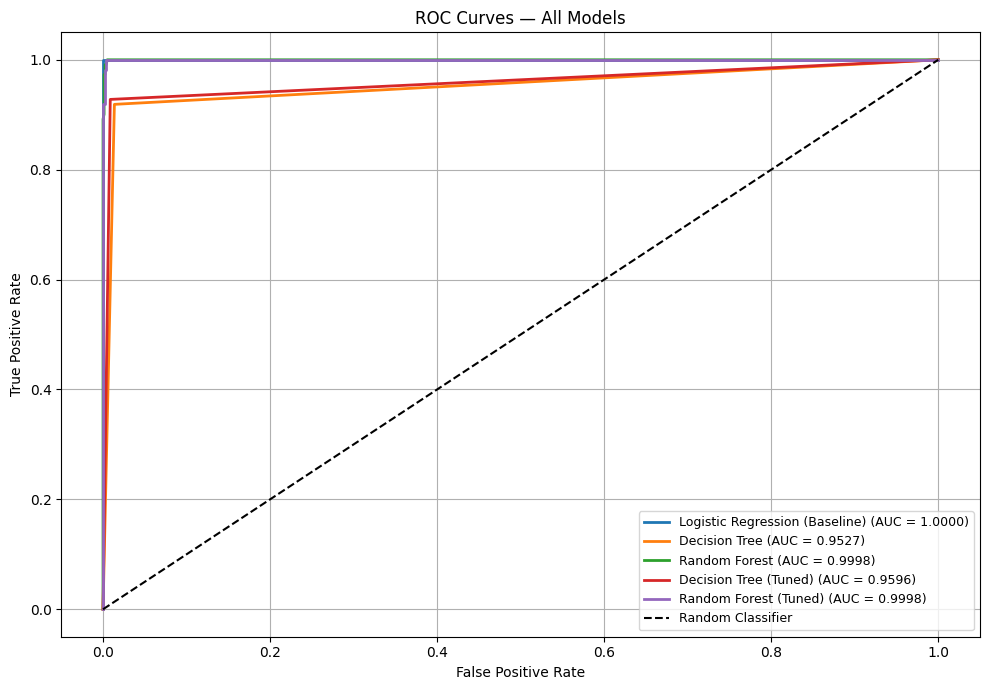


── AUC-ROC Scores ──
                                AUC-ROC
Logistic Regression (Baseline)   1.0000
Random Forest                    0.9998
Random Forest (Tuned)            0.9998
Decision Tree (Tuned)            0.9596
Decision Tree                    0.9527

✅ Best Model: Logistic Regression (Baseline) with AUC = 1.0
   Reason: Highest AUC-ROC means best ability to detect High-Risk customers.
   In banking, minimizing False Negatives (Type-II Error) is critical.


In [19]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
all_models = {
    'Logistic Regression (Baseline)' : y_prob_lr,
    'Decision Tree'                   : y_prob_dt,
    'Random Forest'                   : y_prob_rf,
    'Decision Tree (Tuned)'           : y_prob_dt_tuned,
    'Random Forest (Tuned)'           : y_prob_rf_tuned
}

plt.figure(figsize=(10, 7))
auc_scores = {}

for name, y_prob in all_models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    auc_scores[name] = round(auc, 4)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

# ── AUC comparison table ──────────────────────────────────────────────────────
auc_df = pd.DataFrame.from_dict(auc_scores, orient='index', columns=['AUC-ROC'])
print("\n── AUC-ROC Scores ──")
print(auc_df.sort_values('AUC-ROC', ascending=False))

best_model_name = max(auc_scores, key=auc_scores.get)
print(f"\n✅ Best Model: {best_model_name} with AUC = {auc_scores[best_model_name]}")
print("   Reason: Highest AUC-ROC means best ability to detect High-Risk customers.")
print("   In banking, minimizing False Negatives (Type-II Error) is critical.")

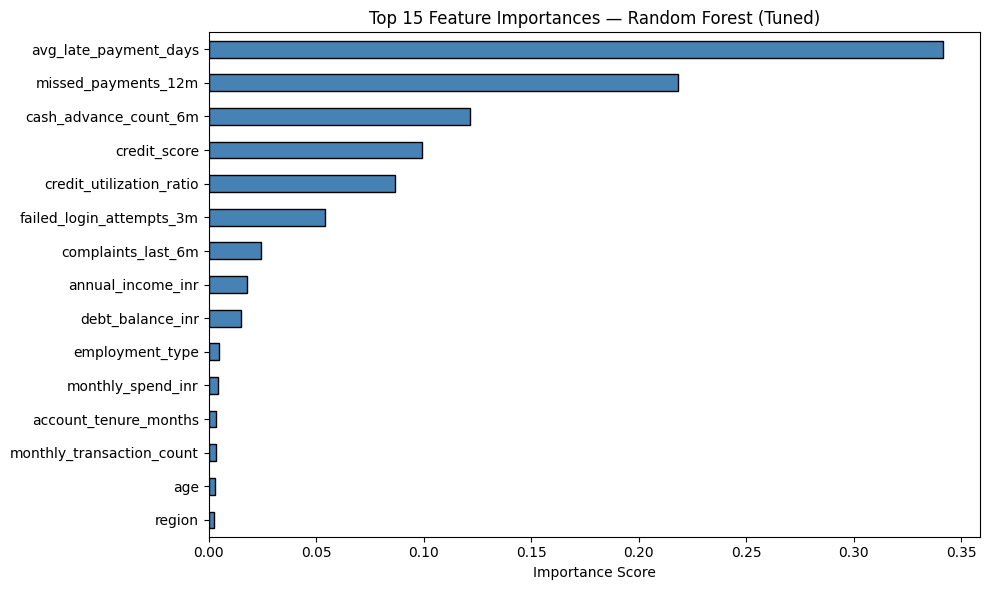


Top 10 most important features:
avg_late_payment_days       0.341586
missed_payments_12m         0.218206
cash_advance_count_6m       0.121309
credit_score                0.099317
credit_utilization_ratio    0.086672
failed_login_attempts_3m    0.053908
complaints_last_6m          0.024426
annual_income_inr           0.017715
debt_balance_inr            0.014980
employment_type             0.004844
dtype: float64


In [ ]:
feat_imp = pd.Series(
    best_rf_tuned.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances — Random Forest (Tuned)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(feat_imp.head(10))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

TN, FP, FN, TP = cm.ravel()

print("\nType-I Error (False Positive):", FP)
print("Type-II Error (False Negative):", FN)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Confusion Matrix
[[801   8]
 [  0 111]]

Accuracy : 0.991304347826087
Precision: 0.9327731092436975
Recall   : 1.0
F1 Score : 0.9652173913043478

Type-I Error (False Positive): 8
Type-II Error (False Negative): 0

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       809
           1       0.93      1.00      0.97       111

    accuracy                           0.99       920
   macro avg       0.97      1.00      0.98       920
weighted avg       0.99      0.99      0.99       920

